In [ ]:
from cellsweep.simulation import simulate_cells
from cellsweep.simulation import simple_simulation
import cellsweep.utils as cs_utils
from cellsweep import denoise_count_matrix, #sparse_em, e_step_numba 
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

cellsweep_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "debug_sim")

In [ ]:
# %load_ext line_profiler

In [3]:
%matplotlib widget

In [4]:
data = simulate_cells(G=10000, N=8000, empty_prob=0.8)

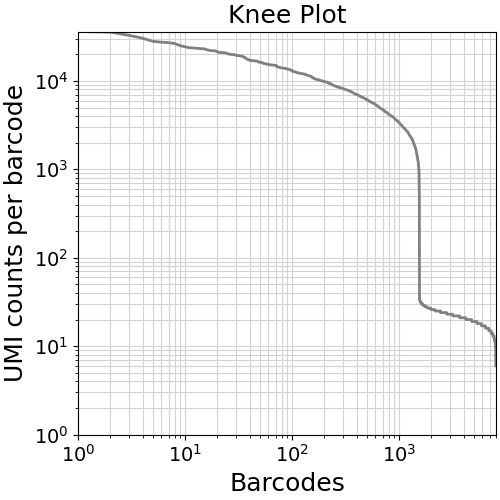

In [5]:
cs_utils.knee_plot(data)

In [6]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellsweep.log")

In [7]:
#%lprun -f e_step_numba denoise_count_matrix(data, max_iter=2, threads=1, adata_out = adata_cellmender_path, log_file = adata_log_path)

In [10]:
denoised_data = denoise_count_matrix(data, verbose=2, threads=8, adata_out = adata_cellmender_path, log_file = adata_log_path)

16:55:13 - INFO - Starting cellsweep denoising at 2025-12-20 16:55:13, cellsweep version 0.1.0
16:55:13 - DEBUG - Number of parameters in the cellsweep model: 51,544 (alpha: 1,543, beta: 1, p_k: 50,000)
16:55:13 - INFO - Performing Sparse EM with 8 Numba thread(s)
16:55:13 - INFO - EM Iter   1: ll=-75015932.475 min_alpha=0.7408 mean_alpha=0.8446 median_alpha=0.8468 max_alpha=0.8598 beta=0.104909
16:55:13 - INFO - EM Iter   2: ll=-74371340.719 min_alpha=0.5763 mean_alpha=0.7571 median_alpha=0.7605 max_alpha=0.8045 beta=0.101838
16:55:13 - INFO - EM Iter   3: ll=-73944275.093 min_alpha=0.4688 mean_alpha=0.6807 median_alpha=0.6843 max_alpha=0.7572 beta=0.096364
16:55:13 - INFO - EM Iter   4: ll=-73720719.959 min_alpha=0.3972 mean_alpha=0.6205 median_alpha=0.6240 max_alpha=0.7139 beta=0.090643
16:55:13 - INFO - EM Iter   5: ll=-73580328.030 min_alpha=0.3453 mean_alpha=0.5721 median_alpha=0.5752 max_alpha=0.6724 beta=0.085092
16:55:13 - INFO - EM Iter   6: ll=-73482629.925 min_alpha=0.3050 

Logging to /Users/mcaskey/Desktop/cellsweep/notebooks/output/debug_sim/cellsweep.log


16:55:14 - INFO - EM Iter  28: ll=-73026935.587 min_alpha=0.0227 mean_alpha=0.2216 median_alpha=0.2250 max_alpha=0.2768 beta=0.025893
16:55:14 - INFO - EM Iter  29: ll=-73021809.942 min_alpha=0.0198 mean_alpha=0.2159 median_alpha=0.2193 max_alpha=0.2703 beta=0.024855
16:55:14 - INFO - EM Iter  30: ll=-73017026.172 min_alpha=0.0171 mean_alpha=0.2104 median_alpha=0.2138 max_alpha=0.2641 beta=0.023874
16:55:14 - INFO - EM Iter  31: ll=-73012558.793 min_alpha=0.0148 mean_alpha=0.2052 median_alpha=0.2087 max_alpha=0.2581 beta=0.022946
16:55:14 - INFO - EM Iter  32: ll=-73008375.823 min_alpha=0.0127 mean_alpha=0.2002 median_alpha=0.2035 max_alpha=0.2523 beta=0.022069
16:55:14 - INFO - EM Iter  33: ll=-73004446.152 min_alpha=0.0109 mean_alpha=0.1955 median_alpha=0.1988 max_alpha=0.2466 beta=0.021238
16:55:14 - INFO - EM Iter  34: ll=-73000739.241 min_alpha=0.0093 mean_alpha=0.1909 median_alpha=0.1942 max_alpha=0.2412 beta=0.020451
16:55:14 - INFO - EM Iter  35: ll=-72997218.104 min_alpha=0.00

In [ ]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [ ]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

In [ ]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'].astype(int) == denoised_data.obs['cellid'].astype(int))

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)